In [46]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [47]:
import warnings
warnings.filterwarnings('ignore')
sns.set(style = 'whitegrid')

In [48]:
df = pd.read_csv('Fraud.csv',on_bad_lines='skip')
df.head()

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,1,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0,0
1,1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0,0
2,1,TRANSFER,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,1,0
3,1,CASH_OUT,181.00,C840083671,181.0,0.00,C38997010,21182.0,0.0,1,0
4,1,PAYMENT,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,0.0,0,0


In [49]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6362620 entries, 0 to 6362619
Data columns (total 11 columns):
 #   Column          Dtype  
---  ------          -----  
 0   step            int64  
 1   type            object 
 2   amount          float64
 3   nameOrig        object 
 4   oldbalanceOrg   float64
 5   newbalanceOrig  float64
 6   nameDest        object 
 7   oldbalanceDest  float64
 8   newbalanceDest  float64
 9   isFraud         int64  
 10  isFlaggedFraud  int64  
dtypes: float64(5), int64(3), object(3)
memory usage: 534.0+ MB


In [50]:
df.columns

Index(['step', 'type', 'amount', 'nameOrig', 'oldbalanceOrg', 'newbalanceOrig',
       'nameDest', 'oldbalanceDest', 'newbalanceDest', 'isFraud',
       'isFlaggedFraud'],
      dtype='object')

In [51]:
df['isFraud'].value_counts()

,count
isFraud,
0,6354407
1,8213


In [52]:
df['isFlaggedFraud'].value_counts()

,count
isFlaggedFraud,
0,6362604
1,16


In [53]:
df.isnull().sum()

,0
step,0
type,0
amount,0
nameOrig,0
oldbalanceOrg,0
newbalanceOrig,0
nameDest,0
oldbalanceDest,0
newbalanceDest,0
isFraud,0


In [54]:
df = df.dropna()
numeric_cols = ['amount','oldbalanceOrg','newbalanceOrig','oldbalanceDest','newbalanceDest']

# Convert everything to numeric (strings → NaN)
df[numeric_cols] = df[numeric_cols].apply(pd.to_numeric, errors='coerce')

# Drop any remaining rows with NaN
df = df.dropna(subset=numeric_cols)

In [55]:

print(df.isnull().sum())


step              0
type              0
amount            0
nameOrig          0
oldbalanceOrg     0
newbalanceOrig    0
nameDest          0
oldbalanceDest    0
newbalanceDest    0
isFraud           0
isFlaggedFraud    0
dtype: int64


In [56]:
round((df['isFraud'].value_counts()[1]/df.shape[0])*100,2)

np.float64(0.13)

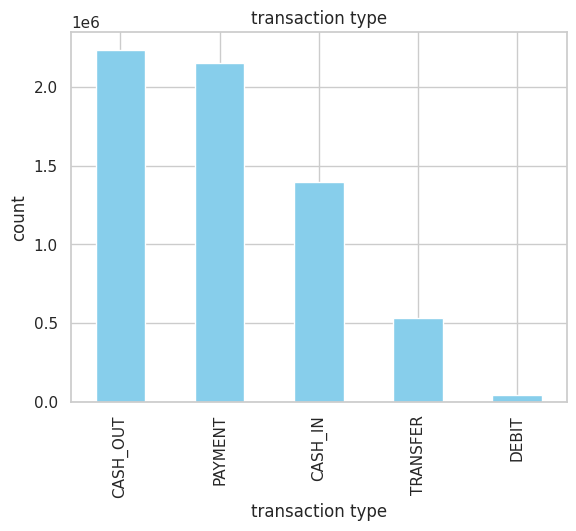

In [57]:
df['type'].value_counts().plot(kind = 'bar',title = 'transaction type',color = 'skyblue')
plt.xlabel('transaction type')
plt.ylabel('count')
plt.show()

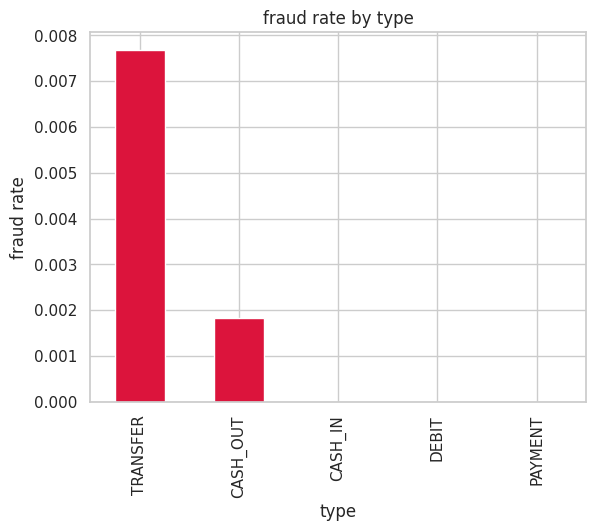

In [58]:
fraud_by_type = df.groupby('type')['isFraud'].mean().sort_values(ascending = False)
fraud_by_type.plot(kind = 'bar',title = 'fraud rate by type',color = 'crimson')
plt.ylabel('fraud rate')
plt.show()

In [59]:
fraud_by_type

,isFraud
type,
TRANSFER,0.007688
CASH_OUT,0.001840
CASH_IN,0.000000
DEBIT,0.000000
PAYMENT,0.000000


In [60]:
df['amount'].describe().astype(float).round(0).astype(int)
df['amount'] = pd.to_numeric(df['amount'], errors='coerce')


In [61]:
# sns.histplot(np.log1p(df['amount']),bins = 100,kde = True,color = 'green')
# plt.title('transcation amount distribution (log)')
# plt.xlabel('log(ampunt +1)')
# plt.show()

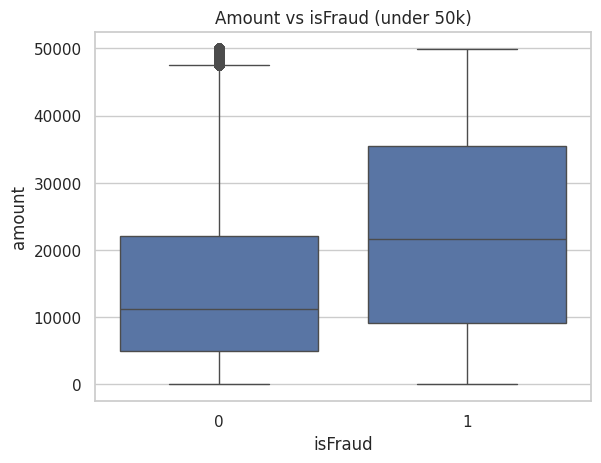

In [62]:
sns.boxplot(data = df[df['amount']<50000],x = 'isFraud',y = 'amount')
plt.title('Amount vs isFraud (under 50k)')
plt.show()

In [63]:
cols = ['oldbalanceOrg', 'newbalanceOrig', 'oldbalanceDest', 'newbalanceDest']
print(df[cols].dtypes)
df[cols] = df[cols].apply(lambda x: pd.to_numeric(x, errors='coerce'))

df['balance_diff_org'] = df['oldbalanceOrg'] - df['newbalanceOrig']
df['balance_diff_dest'] = df['newbalanceDest'] - df['oldbalanceDest']

oldbalanceOrg     float64
newbalanceOrig    float64
oldbalanceDest    float64
newbalanceDest    float64
dtype: object


In [64]:
(df['balance_diff_dest']<0).sum()

np.int64(1238864)

In [65]:
df[['isFraud','step']]=df[['isFraud','step']].astype(int)


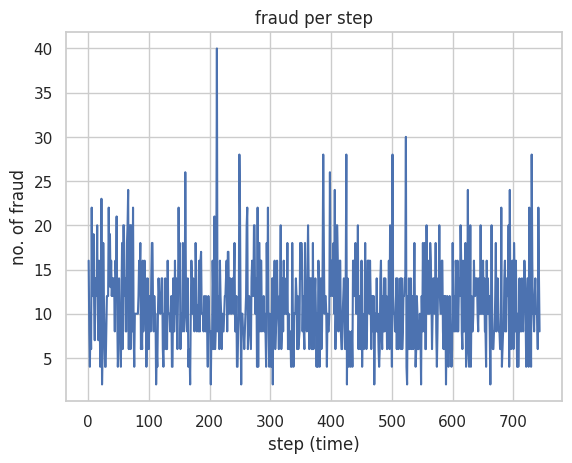

In [66]:
fraud_per_step = df[df['isFraud']==1]['step'].value_counts().sort_index()
plt.plot(fraud_per_step.index,fraud_per_step.values,label = 'Fraud per step')
plt.title('fraud per step')
plt.xlabel('step (time)')
plt.ylabel('no. of fraud')
plt.show()

In [67]:
df.drop(['step'],axis = 1,inplace = True)

In [68]:
top_senders = df['nameOrig'].value_counts().head(10)
top_receiver = df['nameDest'].value_counts().head(10)

In [69]:
top_senders

,count
nameOrig,
C1530544995,3
C545315117,3
C724452879,3
C1784010646,3
C1677795071,3
C1462946854,3
C1065307291,3
C1999539787,3
C2098525306,3


In [70]:
top_receiver

,count
nameDest,
C1286084959,113
C985934102,109
C665576141,105
C2083562754,102
C248609774,101
C1590550415,101
C1789550256,99
C451111351,99
C1360767589,98


In [71]:
fraud_user = df[df['isFraud']== 1]['nameOrig'].value_counts().head(10)
fraud_user

,count
nameOrig,
C1280323807,1
C1305486145,1
C840083671,1
C1420196421,1
C2101527076,1
C1039979813,1
C2089752665,1
C1614818636,1
C40604503,1


In [72]:
fraud_types = df[df['type'].isin(['TRANSFER','CASH_OUT'])]

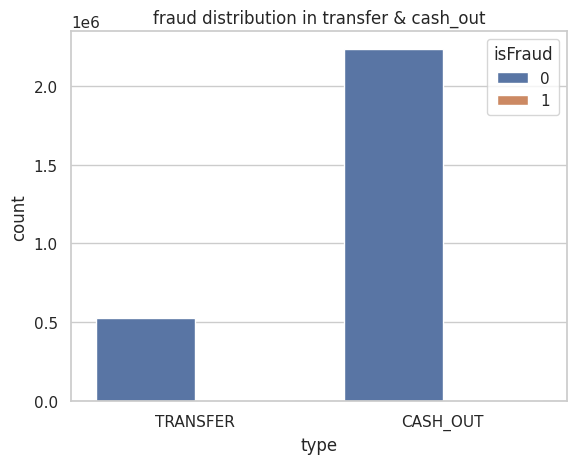

In [73]:
sns.countplot(data = fraud_types ,x = 'type',hue = 'isFraud')
plt.title('fraud distribution in transfer & cash_out')
plt.show()

In [74]:
corr = df[['amount','oldbalanceOrg','newbalanceOrig','oldbalanceDest','newbalanceDest','isFraud']].corr()

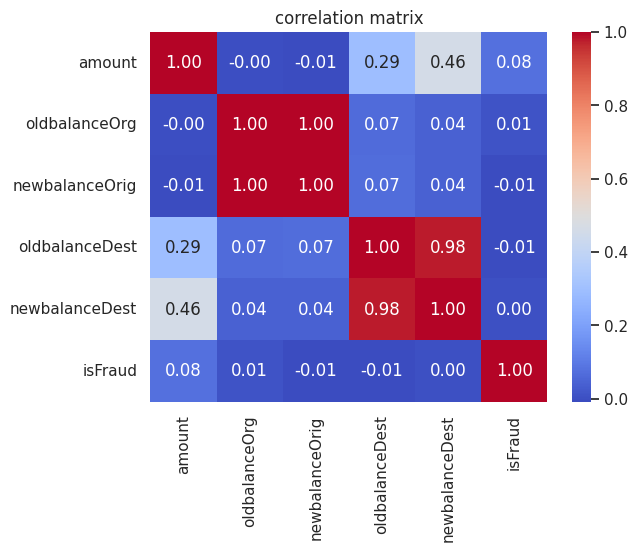

In [75]:
sns.heatmap(corr,annot= True,cmap = 'coolwarm',fmt ='.2f')
plt.title('correlation matrix')
plt.show()

In [76]:
zero_after_transfer  = df[(df['oldbalanceOrg']>0)&(df['newbalanceOrig']==0)&(df['type'].isin(['TRANSFER','CASH_out']))]

In [77]:
zero_after_transfer.head()

,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud,balance_diff_org,balance_diff_dest
2,TRANSFER,181.00,C1305486145,181.00,0.0,C553264065,0.00,0.00,1,0,181.00,0.00
19,TRANSFER,215310.30,C1670993182,705.00,0.0,C1100439041,22425.00,0.00,0,0,705.00,-22425.00
24,TRANSFER,311685.89,C1984094095,10835.00,0.0,C932583850,6267.00,2719172.89,0,0,10835.00,2712905.89
78,TRANSFER,42712.39,C283039401,10363.39,0.0,C1330106945,57901.66,24044.18,0,0,10363.39,-33857.48
123,TRANSFER,330757.04,C1494346128,103657.00,0.0,C564160838,79676.00,1254956.07,0,0,103657.00,1175280.07


In [78]:
df['isFraud'].value_counts()

,count
isFraud,
0,6354407
1,8213


In [79]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.metrics import confusion_matrix

In [80]:
df_model = df.drop(['nameOrig','nameDest','isFlaggedFraud'],axis = 1)

In [81]:
categorical = ['type']
numeric = ['amount','oldbalanceOrg','newbalanceOrig','oldbalanceDest','newbalanceDest']

In [82]:
y = df_model['isFraud']
x = df_model.drop('isFraud',axis = 1)


In [83]:
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size = 0.3,stratify = y)

In [84]:
preprocessor = ColumnTransformer(
    transformers = [
        ('num',StandardScaler(),numeric),
        ('cat',OneHotEncoder(drop = 'first',handle_unknown = 'ignore'),categorical
         )
    ],
    remainder ='drop'
)

In [85]:
pipeline = Pipeline([
    ('prep',preprocessor),
    ('clf',LogisticRegression(class_weight='balanced',max_iter =1000))
])

In [86]:
print(x_train.isna().sum())
pipeline.fit(x_train,y_train)



type                 0
amount               0
oldbalanceOrg        0
newbalanceOrig       0
oldbalanceDest       0
newbalanceDest       0
balance_diff_org     0
balance_diff_dest    0
dtype: int64


Pipeline(steps=[('prep',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['amount', 'oldbalanceOrg',
                                                   'newbalanceOrig',
                                                   'oldbalanceDest',
                                                   'newbalanceDest']),
                                                 ('cat',
                                                  OneHotEncoder(drop='first',
                                                                handle_unknown='ignore'),
                                                  ['type'])])),
                ('clf',
                 LogisticRegression(class_weight='balanced', max_iter=1000))])

In [87]:
y_pred = pipeline.predict(x_test)
y_pred

array([0, 0, 0, ..., 0, 1, 0])

In [88]:
confusion_matrix(y_test,y_pred)

array([[1800945,  105377],
       [    124,    2340]])

In [89]:
pipeline.score(x_test,y_test)*100

94.472874381937

In [90]:
import joblib
joblib.dump(pipeline,'fraud_detection_pipeline.pkl')


['fraud_detection_pipeline.pkl']